#  Formula 1 Dataset Explorer
### Your Beginner-Friendly Guide to Understanding F1 Data

---
**Run each cell from top to bottom.** Each section explores one "table" of data from FastF1.

Think of FastF1 like a **TV remote for F1 data** — you point it at a race, press load, and it gives you all the data from that event split into several tables (called DataFrames in Python).

Disclaimer : This is just a ipynb script made for the purpose of knwoing the dataset,this doesn;t correlate in any part of the project,it;s just for practicing
It was generated with claude prompts

---
###  Tables we'll explore:
| # | Table | What it's like |
|---|-------|---------------|
| 1 | `session.results` | The final scoreboard / leaderboard |
| 2 | `session.laps` | Every single lap by every driver |
| 3 | `session.weather_data` | Live weather during the race |
| 4 | Telemetry (per lap) | Real-time car sensor data (speed, braking, etc.) |

---
##  STEP 0 — Import Libraries & Load the Session
Before doing anything, we need to:
1. **Import** the tools we'll use
2. **Load** a specific race session from FastF1

We're loading **2024 Bahrain Grand Prix — Qualifying** (same as first.ipynb).

In [ ]:
#  Importing libraries (tools we need)
import fastf1                          # The library that gives us F1 data
import pandas as pd                    # Pandas = tool for working with tables
import matplotlib.pyplot as plt        # Matplotlib = tool for making charts
import matplotlib.patches as mpatches # For custom chart legend

#  Make our charts look nicer
plt.style.use('dark_background')       # Dark theme — very F1-like!

#  LOAD the session
# Arguments: (year, race name, session type)
# Session types: 'Q' = Qualifying | 'R' = Race | 'FP1' = Free Practice 1
session = fastf1.get_session(2024, 'Bahrain Grand Prix', 'Q')
session.load()  # This fetches the data from the internet/cache

print(" Session loaded successfully!")
print(f" Event: {session.event['EventName']}")
print(f" Date: {session.event['EventDate']}")
print(f" Session Type: {session.name}")

req         WARNING 	DEFAULT CACHE ENABLED! (45.76 MB) C:\Users\sukir\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']


✅ Session loaded successfully!
📍 Event: Bahrain Grand Prix
📅 Date: 2024-03-02 00:00:00
🏁 Session Type: Qualifying


---
##  TABLE 1: `session.results` — The Driver Leaderboard

**What is this?**  
Imagine the **final standings board** you see after qualifying on TV. Each row is ONE driver. It shows their name, team, position, and their lap times in Q1, Q2, and Q3.

>  In qualifying, drivers do multiple laps and only their **best time** counts. Q1 → Q2 → Q3 are elimination rounds.

In [ ]:
#  Let's start with the basics — what does this table look like?

results = session.results  # Save it in a variable for easy access

# .shape tells you (number of rows, number of columns)
print(f" Shape: {results.shape}")
print(f"   → {results.shape[0]} rows (one per driver)")
print(f"   → {results.shape[1]} columns (different pieces of info)")

print(f"\n All column names:")
for col in results.columns:
    print(f"   • {col}")

📐 Shape: (20, 22)
   → 20 rows (one per driver)
   → 22 columns (different pieces of info)

📋 All column names:
   • DriverNumber
   • BroadcastName
   • Abbreviation
   • DriverId
   • TeamName
   • TeamColor
   • TeamId
   • FirstName
   • LastName
   • FullName
   • HeadshotUrl
   • CountryCode
   • Position
   • ClassifiedPosition
   • GridPosition
   • Q1
   • Q2
   • Q3
   • Time
   • Status
   • Points
   • Laps


In [3]:
# 🔍 Look at the most important columns for each driver
# [['col1', 'col2']] means: only show these specific columns

important_cols = ['Abbreviation', 'FullName', 'TeamName', 'Position', 'Q1', 'Q2', 'Q3']
print("🏆 QUALIFYING RESULTS (Top 10 drivers):")
print("=" * 70)

# .head(10) = show only the first 10 rows
# .to_string() = print it nicely without cutting columns
print(results[important_cols].head(10).to_string(index=False))

🏆 QUALIFYING RESULTS (Top 10 drivers):
Abbreviation        FullName        TeamName  Position                     Q1                     Q2                     Q3
         VER  Max Verstappen Red Bull Racing       1.0 0 days 00:01:30.031000 0 days 00:01:29.374000 0 days 00:01:29.179000
         LEC Charles Leclerc         Ferrari       2.0 0 days 00:01:30.243000 0 days 00:01:29.165000 0 days 00:01:29.407000
         RUS  George Russell        Mercedes       3.0 0 days 00:01:30.350000 0 days 00:01:29.922000 0 days 00:01:29.485000
         SAI    Carlos Sainz         Ferrari       4.0 0 days 00:01:29.909000 0 days 00:01:29.573000 0 days 00:01:29.507000
         PER    Sergio Perez Red Bull Racing       5.0 0 days 00:01:30.221000 0 days 00:01:29.932000 0 days 00:01:29.537000
         ALO Fernando Alonso    Aston Martin       6.0 0 days 00:01:30.179000 0 days 00:01:29.801000 0 days 00:01:29.542000
         NOR    Lando Norris         McLaren       7.0 0 days 00:01:30.143000 0 days 00:01:29

C:\Users\sukir\AppData\Local\Temp\ipykernel_19792\3999849030.py:47: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sukir\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


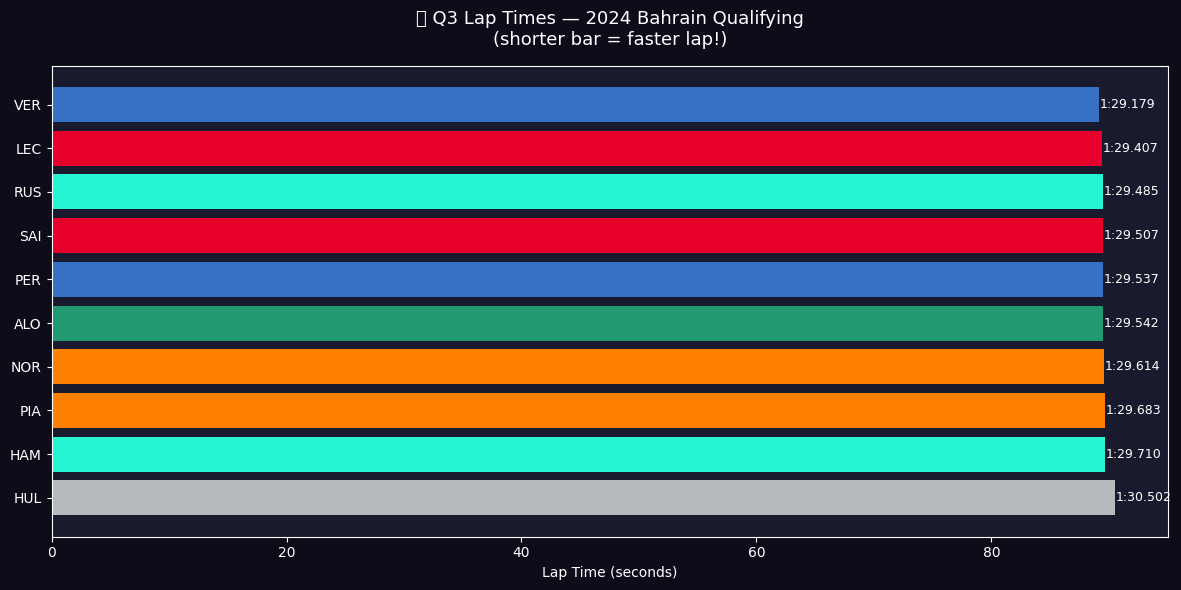


💡 Verstappen (VER) should be at the top with the shortest bar = fastest lap!


In [ ]:
#  VISUALIZE: Bar chart of Q3 lap times (top 10 qualifiers)
# Q3 is the final round — only top 10 drivers make it here

# Filter: only keep drivers who have a Q3 time and sort by position
q3_drivers = results.dropna(subset=['Q3']).sort_values('Position').head(10).copy()

# Convert Q3 times to seconds (easier to plot than timedelta)
q3_drivers['Q3_seconds'] = q3_drivers['Q3'].dt.total_seconds()

# Define team colors (to match real F1 colors!)
team_colors = {
    'Red Bull Racing': '#3671C6',
    'Ferrari': '#E8002D',
    'Mercedes': '#27F4D2',
    'McLaren': '#FF8000',
    'Aston Martin': '#229971',
    'Alpine': '#FF87BC',
    'Williams': '#64C4FF',
    'AlphaTauri': '#6692FF',
    'Alfa Romeo': '#C92D4B',
    'Haas F1 Team': '#B6BABD',
    'RB': '#6692FF',
    'Kick Sauber': '#52E252',
}

# Assign a color to each driver based on their team
colors = [team_colors.get(team, '#FFFFFF') for team in q3_drivers['TeamName']]

# Create the chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(q3_drivers['Abbreviation'], q3_drivers['Q3_seconds'], color=colors)

# Add labels to bars showing the actual time
for bar, sec in zip(bars, q3_drivers['Q3_seconds']):
    mins = int(sec // 60)
    secs = sec % 60
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{mins}:{secs:.3f}', va='center', color='white', fontsize=9)

ax.set_xlabel('Lap Time (seconds)', color='white')
ax.set_title('🏆 Q3 Lap Times — 2024 Bahrain Qualifying\n(shorter bar = faster lap!)', 
             color='white', fontsize=13, pad=15)
ax.invert_yaxis()  # Position 1 on top
ax.tick_params(colors='white')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0d0d1a')
plt.tight_layout()
plt.show()
print("\n💡 Verstappen (VER) should be at the top with the shortest bar = fastest lap!")

---
##  TABLE 2: `session.laps` — Every Single Lap

**What is this?**  
This is the **BIG table**. Imagine writing down every single lap every driver did during the session. That's what this is. If a driver does 8 laps in qualifying, they have 8 rows in this table.

>  **Lap** = One complete loop around the track. In qualifying, drivers go out and do several laps trying to set their best time.

In [ ]:
#  Basic info about the laps table

laps = session.laps  # Save it in a variable

print(f" Shape: {laps.shape}")
print(f"   → {laps.shape[0]} total laps in this session")
print(f"   → {laps.shape[1]} columns of info for each lap")
print(f"\n Drivers in this session: {sorted(laps['Driver'].unique())}")
print(f"   → {laps['Driver'].nunique()} drivers total")
print(f"\n How many laps did each driver do?")
print(laps.groupby('Driver').size().sort_values(ascending=False).to_string())

📐 Shape: (267, 31)
   → 267 total laps in this session
   → 31 columns of info for each lap

👥 Drivers in this session: ['ALB', 'ALO', 'BOT', 'GAS', 'HAM', 'HUL', 'LEC', 'MAG', 'NOR', 'OCO', 'PER', 'PIA', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'ZHO']
   → 20 drivers total

📋 How many laps did each driver do?
Driver
LEC    19
PIA    18
HAM    18
HUL    18
SAI    18
PER    17
RUS    17
VER    17
NOR    15
ALO    14
ALB    12
MAG    12
STR    12
RIC    12
TSU    12
GAS     9
OCO     9
BOT     6
SAR     6
ZHO     6


In [6]:
# 🔍 Let's understand each column by looking at one driver's laps
# .pick_drivers() is a FastF1 shortcut to filter by driver abbreviation

ver_laps = laps.pick_drivers('VER')  # Get only Verstappen's laps

# Key columns explained
key_cols = ['LapNumber', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
            'Compound', 'FreshTyre', 'Stint', 'IsAccurate']

print("🔵 VERSTAPPEN's laps — key columns explained:")
print("=" * 80)
print(ver_laps[key_cols].to_string(index=False))
print("\n💡 COLUMN GUIDE:")
print("   LapNumber   → Which lap number it was (1, 2, 3...)")
print("   LapTime     → How long the whole lap took (mins:secs format)")
print("   Sector1/2/3 → Lap is split into 3 sectors, this is each sector's time")
print("   Compound    → Tire type: SOFT (fastest, wears out), MEDIUM, HARD (durable)")
print("   FreshTyre   → True = brand new tire | False = already used tire")
print("   Stint       → Which stint (1 = before first pit stop, 2 = after, etc.)")
print("   IsAccurate  → True = this lap time is reliable data (use these for analysis!)")

🔵 VERSTAPPEN's laps — key columns explained:
 LapNumber                LapTime            Sector1Time            Sector2Time            Sector3Time Compound  FreshTyre  Stint  IsAccurate
       1.0                    NaT                    NaT 0 days 00:00:46.454000 0 days 00:00:27.668000     SOFT       True    1.0       False
       2.0 0 days 00:01:30.031000 0 days 00:00:28.787000 0 days 00:00:38.580000 0 days 00:00:22.664000     SOFT       True    1.0        True
       3.0 0 days 00:02:08.726000 0 days 00:00:37.524000 0 days 00:00:56.168000 0 days 00:00:35.034000     SOFT       True    1.0       False
       4.0                    NaT                    NaT 0 days 00:00:46.144000 0 days 00:00:29.156000     SOFT      False    2.0       False
       5.0 0 days 00:01:30.160000 0 days 00:00:28.822000 0 days 00:00:38.767000 0 days 00:00:22.571000     SOFT      False    2.0        True
       6.0 0 days 00:01:42.855000 0 days 00:00:32.800000 0 days 00:00:42.210000 0 days 00:00:27.845000 

In [7]:
# 🥇 Finding the fastest lap of the whole session
# .pick_accurate() = only keep laps with 100% reliable data (removes outlaps, inlaps, etc.)

clean_laps = laps.pick_accurate()  # Only valid, complete laps

# Sort by lap time (fastest first) and show top 10
fastest_laps = clean_laps.sort_values('LapTime').head(10)

print("⚡ TOP 10 FASTEST LAPS of the session:")
print("=" * 55)
display_cols = ['Driver', 'Team', 'LapTime', 'Compound', 'LapNumber']
print(fastest_laps[display_cols].to_string(index=False))
print("\n💡 These are the fastest laps of the ENTIRE qualifying session from ALL drivers!")

⚡ TOP 10 FASTEST LAPS of the session:
Driver            Team                LapTime Compound  LapNumber
   LEC         Ferrari 0 days 00:01:29.165000     SOFT       12.0
   VER Red Bull Racing 0 days 00:01:29.179000     SOFT       16.0
   VER Red Bull Racing 0 days 00:01:29.374000     SOFT        8.0
   LEC         Ferrari 0 days 00:01:29.407000     SOFT       18.0
   VER Red Bull Racing 0 days 00:01:29.421000     SOFT       13.0
   LEC         Ferrari 0 days 00:01:29.480000     SOFT       15.0
   RUS        Mercedes 0 days 00:01:29.485000     SOFT       16.0
   SAI         Ferrari 0 days 00:01:29.507000     SOFT       17.0
   PER Red Bull Racing 0 days 00:01:29.537000     SOFT       16.0
   ALO    Aston Martin 0 days 00:01:29.542000     SOFT       13.0

💡 These are the fastest laps of the ENTIRE qualifying session from ALL drivers!


In [ ]:
# 📊 VISUALIZE: Compare lap times for top 5 drivers across all their laps
# This shows how drivers IMPROVED (or got slower) lap by lap

top5_drivers = results.sort_values('Position').head(5)['Abbreviation'].tolist()
print(f"Plotting laps for: {top5_drivers}")

fig, ax = plt.subplots(figsize=(13, 7))

for driver in top5_drivers:
    driver_laps = clean_laps[clean_laps['Driver'] == driver].copy()
    if driver_laps.empty:
        continue
    # Convert timedelta to total seconds for easy plotting
    driver_laps['LapTime_s'] = driver_laps['LapTime'].dt.total_seconds()
    
    # Get team color
    team = driver_laps['Team'].iloc[0]
    color = team_colors.get(team, '#FFFFFF')
    
    ax.plot(driver_laps['LapNumber'], driver_laps['LapTime_s'],
            marker='o', label=driver, color=color, linewidth=2, markersize=6)

ax.set_xlabel('Lap Number', color='white', fontsize=12)
ax.set_ylabel('Lap Time (seconds)', color='white', fontsize=12)
ax.set_title('🔄 Lap Times per Lap — Top 5 Qualifiers\n(lower = faster!)', 
             color='white', fontsize=13, pad=15)
ax.legend(fontsize=11, facecolor='#1a1a2e', labelcolor='white')
ax.tick_params(colors='white')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0d0d1a')
plt.tight_layout()
plt.show()
print("\n💡 You can see drivers get faster as they push harder in each round!")
print("   Outlaps (slow warm-up laps) will appear as high spikes — those are normal.")

In [ ]:
# 📊 VISUALIZE: Sector-by-sector breakdown for the top 5 drivers (best lap only)
# Understanding sectors: Track is split into 3 mini-segments. Where did each driver win or lose time?

sector_data = []
for driver in top5_drivers:
    driver_laps = clean_laps[clean_laps['Driver'] == driver].copy()
    if driver_laps.empty:
        continue
    # Get the single best lap for this driver
    best_lap = driver_laps.sort_values('LapTime').iloc[0]
    s1 = best_lap['Sector1Time'].total_seconds() if pd.notna(best_lap['Sector1Time']) else None
    s2 = best_lap['Sector2Time'].total_seconds() if pd.notna(best_lap['Sector2Time']) else None
    s3 = best_lap['Sector3Time'].total_seconds() if pd.notna(best_lap['Sector3Time']) else None
    if s1 and s2 and s3:
        sector_data.append({'Driver': driver, 'Team': best_lap['Team'], 'S1': s1, 'S2': s2, 'S3': s3})

sector_df = pd.DataFrame(sector_data)

x = range(len(sector_df))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

b1 = ax.bar([i - width for i in x], sector_df['S1'], width, label='Sector 1', color='#FF4655', alpha=0.9)
b2 = ax.bar([i for i in x],          sector_df['S2'], width, label='Sector 2', color='#00D2BE', alpha=0.9)
b3 = ax.bar([i + width for i in x],  sector_df['S3'], width, label='Sector 3', color='#FFF200', alpha=0.9)

ax.set_xticks(list(x))
ax.set_xticklabels(sector_df['Driver'], color='white', fontsize=12)
ax.set_ylabel('Time (seconds)', color='white')
ax.set_title('📐 Best Lap — Sector Times Breakdown\n(shorter bar = faster sector!)', 
             color='white', fontsize=13, pad=15)
ax.legend(fontsize=11, facecolor='#1a1a2e', labelcolor='white')
ax.tick_params(colors='white')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0d0d1a')
plt.tight_layout()
plt.show()
print("\n💡 This shows WHERE on track each driver was faster or slower!")
print("   A driver might lose time in S1 but gain it back in S2 or S3.")

---
## 🌦️ TABLE 3: `session.weather_data` — Live Weather

**What is this?**  
Imagine a weather station at the track recording conditions **every few seconds** during the session. That's this table. Weather is HUGE in F1 — rain can completely change the race!

> 💡 **Track temperature** matters more than **air temperature** in F1. Hot track = tires wear faster. Cold track = less grip.

In [ ]:
# 👀 Look at the weather data

weather = session.weather_data

print(f"📐 Shape: {weather.shape}")
print(f"   → {weather.shape[0]} weather recordings (taken every few seconds!)")
print(f"   → {weather.shape[1]} columns")
print(f"\n📋 Columns: {weather.columns.tolist()}")
print("\n📊 First 5 readings:")
print(weather.head().to_string(index=False))
print("\n📈 Summary stats:")
print(weather[['AirTemp', 'TrackTemp', 'Humidity', 'WindSpeed']].describe().round(2))

In [ ]:
# 📊 VISUALIZE: How did weather change during the session?

# Convert time to minutes for easier reading on the x-axis
weather = weather.copy()
weather['Minutes'] = weather['Time'].dt.total_seconds() / 60

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.patch.set_facecolor('#0d0d1a')

# Plot 1: Air vs Track Temperature
axes[0].plot(weather['Minutes'], weather['AirTemp'], color='#FFD700', label='Air Temp', linewidth=2)
axes[0].plot(weather['Minutes'], weather['TrackTemp'], color='#FF4655', label='Track Temp', linewidth=2, linestyle='--')
axes[0].set_ylabel('Temperature (°C)', color='white')
axes[0].set_title('🌡️ Air & Track Temperature over the Session', color='white', fontsize=11)
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')
axes[0].set_facecolor('#1a1a2e')
axes[0].tick_params(colors='white')

# Plot 2: Humidity
axes[1].fill_between(weather['Minutes'], weather['Humidity'], color='#00D2BE', alpha=0.5)
axes[1].plot(weather['Minutes'], weather['Humidity'], color='#00D2BE', linewidth=2)
axes[1].set_ylabel('Humidity (%)', color='white')
axes[1].set_title('💧 Humidity over the Session', color='white', fontsize=11)
axes[1].set_facecolor('#1a1a2e')
axes[1].tick_params(colors='white')

# Plot 3: Wind Speed
axes[2].fill_between(weather['Minutes'], weather['WindSpeed'], color='#9B59B6', alpha=0.5)
axes[2].plot(weather['Minutes'], weather['WindSpeed'], color='#9B59B6', linewidth=2)
axes[2].set_xlabel('Session Time (minutes)', color='white')
axes[2].set_ylabel('Wind Speed (m/s)', color='white')
axes[2].set_title('💨 Wind Speed over the Session', color='white', fontsize=11)
axes[2].set_facecolor('#1a1a2e')
axes[2].tick_params(colors='white')

plt.tight_layout(pad=2)
plt.show()
print("\n💡 If it starts raining, you'd see a spike in humidity — and teams would switch to wet tires!")

---
## 🚗 TABLE 4: Telemetry — Inside the Car, Real-Time!

**What is this?**  
Imagine sensors inside the cockpit recording **EVERYTHING** the car and driver does — thousands of times per lap! Every throttle press, every brake, the exact speed at each corner — all captured.

> 💡 Telemetry = data sent FROM the car TO the team's engineers in real time. This is literally what F1 engineers watch on their screens during a race!

To get telemetry, we first pick a **specific lap** by a **specific driver**.

In [ ]:
# 👀 Get Verstappen's fastest lap telemetry

# Step 1: Get VER's laps
ver_laps = laps.pick_drivers('VER').pick_accurate()

# Step 2: Get the single fastest lap
fastest_ver_lap = ver_laps.sort_values('LapTime').iloc[0]
print(f"🔵 Analyzing VER's fastest lap:")
print(f"   Lap Number : {fastest_ver_lap['LapNumber']}")
print(f"   Lap Time   : {fastest_ver_lap['LapTime']}")
print(f"   Compound   : {fastest_ver_lap['Compound']}")

# Step 3: Get telemetry for that lap
# add_distance() adds a 'Distance' column = how far into the lap (in meters) the car is
telemetry = fastest_ver_lap.get_telemetry().add_distance()

print(f"\n📐 Telemetry shape: {telemetry.shape}")
print(f"   → {telemetry.shape[0]} data points in ONE single lap!")
print(f"\n📋 Telemetry columns: {telemetry.columns.tolist()}")
print("\n📊 First 5 readings:")
print(telemetry[['Distance', 'Speed', 'Throttle', 'Brake', 'nGear', 'RPM', 'DRS']].head().to_string(index=False))

In [ ]:
# 📊 VISUALIZE: The full telemetry dashboard for Verstappen's fastest lap!
# This is what F1 engineers actually look at!

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.patch.set_facecolor('#0d0d1a')
fig.suptitle("🏎️ VER — Fastest Lap Telemetry Dashboard", 
             color='white', fontsize=15, fontweight='bold', y=1.01)

dist = telemetry['Distance']

# 1. Speed trace — the most iconic telemetry chart!
axes[0].plot(dist, telemetry['Speed'], color='#FF4655', linewidth=1.5)
axes[0].fill_between(dist, telemetry['Speed'], alpha=0.2, color='#FF4655')
axes[0].set_ylabel('Speed\n(km/h)', color='white', fontsize=10)
axes[0].set_facecolor('#1a1a2e')
axes[0].tick_params(colors='white')
axes[0].set_title('Speed — higher = going faster down the straight', color='#FF4655', fontsize=10)

# 2. Throttle — 0% = foot off, 100% = full throttle
axes[1].plot(dist, telemetry['Throttle'], color='#39FF14', linewidth=1.5)
axes[1].fill_between(dist, telemetry['Throttle'], alpha=0.2, color='#39FF14')
axes[1].set_ylabel('Throttle\n(%)', color='white', fontsize=10)
axes[1].set_facecolor('#1a1a2e')
axes[1].tick_params(colors='white')
axes[1].set_title('Throttle — spikes down = lifting off into a corner', color='#39FF14', fontsize=10)

# 3. Brake — True/False plotted as 1/0
brake_numeric = telemetry['Brake'].astype(int)
axes[2].fill_between(dist, brake_numeric, color='#FF8C00', alpha=0.7, step='pre')
axes[2].set_ylabel('Braking\n(1=yes)', color='white', fontsize=10)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Off', 'ON'], color='white')
axes[2].set_facecolor('#1a1a2e')
axes[2].tick_params(colors='white')
axes[2].set_title('Braking — orange spikes = driver pressing brake pedal', color='#FF8C00', fontsize=10)

# 4. Gear — which gear the car is in
axes[3].plot(dist, telemetry['nGear'], color='#00D2BE', linewidth=1.5, drawstyle='steps-post')
axes[3].set_ylabel('Gear', color='white', fontsize=10)
axes[3].set_yticks(range(1, 9))
axes[3].set_facecolor('#1a1a2e')
axes[3].tick_params(colors='white')
axes[3].set_title('Gear — drops at corners (downshift) then climbs on straights (upshift)', color='#00D2BE', fontsize=10)

# 5. DRS — Drag Reduction System (open wing for extra speed on straights)
drs_active = (telemetry['DRS'] >= 10).astype(int)  # DRS value >= 10 means it's open
axes[4].fill_between(dist, drs_active, color='#9B59B6', alpha=0.7, step='pre')
axes[4].set_ylabel('DRS\n(1=open)', color='white', fontsize=10)
axes[4].set_yticks([0, 1])
axes[4].set_yticklabels(['Closed', 'OPEN'], color='white')
axes[4].set_xlabel('Distance into Lap (meters)', color='white', fontsize=11)
axes[4].set_facecolor('#1a1a2e')
axes[4].tick_params(colors='white')
axes[4].set_title('DRS — purple sections = wing open for extra top speed!', color='#9B59B6', fontsize=10)

plt.tight_layout(pad=1.5)
plt.show()
print("\n💡 THIS is what F1 engineers watch live during the race!")
print("   The drops in speed + brake spikes + gear drops all happen at CORNERS.")
print("   The flat-top speed sections with full throttle = STRAIGHTS.")

In [ ]:
# 📊 EXTRA: Compare speed trace of VER vs LEC (top 2 drivers)
# This is how engineers find where one driver is faster than another!

lec_laps = laps.pick_drivers('LEC').pick_accurate()
fastest_lec_lap = lec_laps.sort_values('LapTime').iloc[0]
lec_tel = fastest_lec_lap.get_telemetry().add_distance()

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d0d1a')

ax.plot(telemetry['Distance'], telemetry['Speed'], 
        color='#3671C6', label='VER (Red Bull)', linewidth=2)
ax.plot(lec_tel['Distance'], lec_tel['Speed'], 
        color='#E8002D', label='LEC (Ferrari)', linewidth=2, linestyle='--')

ax.set_xlabel('Distance into Lap (meters)', color='white', fontsize=12)
ax.set_ylabel('Speed (km/h)', color='white', fontsize=12)
ax.set_title('⚡ Speed Comparison: VER vs LEC — Best Lap\n(where one line is higher = that driver is going faster at that point)', 
             color='white', fontsize=12, pad=15)
ax.legend(fontsize=12, facecolor='#1a1a2e', labelcolor='white')
ax.tick_params(colors='white')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.show()
print("\n💡 Where VER's blue line is ABOVE LEC's red line = Verstappen was going faster there!")
print("   This tells engineers: 'We need to improve in sector X, driver is losing time there.'")

---
## 🧩 BONUS: Useful Commands Cheat Sheet
Here are **all the commands** you'll use over and over when exploring data:

In [ ]:
# ============================================================
# 🗺️  CHEAT SHEET — Run this cell anytime to remember commands!
# ============================================================

df = session.laps  # We'll use laps as our example

# --- UNDERSTANDING THE TABLE ---
print("--- 1. UNDERSTANDING THE TABLE ---")
print(f"Shape (rows, cols) : {df.shape}")
print(f"Total rows         : {len(df)}")
print(f"Column names       : {df.columns.tolist()[:5]}...")  # first 5 cols

# --- PEEKING AT DATA ---
print("\n--- 2. PEEKING AT DATA ---")
print(df[['Driver', 'LapTime', 'Compound']].head(3).to_string(index=False))  # First 3 rows
# df.tail(3)   → Last 3 rows
# df.sample(3) → 3 RANDOM rows

# --- FILTERING ---
print("\n--- 3. FILTERING ---")
# Keep only rows where a condition is TRUE:
soft_laps = df[df['Compound'] == 'SOFT']         # Only soft tire laps
fast_laps = df[df['LapTime'] < pd.Timedelta('1:30')]  # Laps under 1m30s
print(f"Soft tire laps: {len(soft_laps)} | Sub-1:30 laps: {len(fast_laps)}")

# --- SORTING ---
print("\n--- 4. SORTING ---")
# Sort by a column (ascending = small first, descending = big first)
by_time = df.sort_values('LapTime', ascending=True)  # Fastest first
print(f"Fastest lap in session: {by_time['LapTime'].iloc[0]}")

# --- GROUPING ---
print("\n--- 5. GROUPING (group by driver, then calculate something) ---")
avg_per_driver = df.groupby('Driver')['LapTime'].count()  # How many laps each driver did
print(avg_per_driver.head())

# --- BASIC STATS ---
print("\n--- 6. BASIC STATS ---")
# .min(), .max(), .mean(), .median() work on numeric columns
print(f"Min Lap Time: {df['LapTime'].min()}")
print(f"Max Lap Time: {df['LapTime'].max()}")

# --- MISSING DATA ---
print("\n--- 7. MISSING DATA (NaN = empty cell) ---")
missing = df.isnull().sum()
print(missing[missing > 0].head(5))  # Only show columns that HAVE missing values

print("\n✅ That's your cheat sheet! These 7 operations cover 90% of data exploration.")

---
## 🎓 Summary — What You've Learned!

| Table | Variable | What it represents |
|-------|----------|-------------------|
| **Results** | `session.results` | One row per driver — qualifying standings, Q1/Q2/Q3 times |
| **Laps** | `session.laps` | One row per lap — every lap every driver did, with sector times, tires |
| **Weather** | `session.weather_data` | One row per few seconds — temp, humidity, wind, rain |
| **Telemetry** | `lap.get_telemetry()` | One row per sensor reading — speed, throttle, brake, gear, DRS |

---

### 🛠️ Your Go-To Thought Process
1. **Load** → `session = fastf1.get_session(...)` then `session.load()`
2. **Inspect** → `.shape`, `.columns`, `.head()`, `.dtypes`
3. **Clean** → `.pick_accurate()`, `.dropna()`, filter bad rows
4. **Filter** → `[df['column'] == 'value']`, `.pick_drivers('VER')`
5. **Analyze** → `.sort_values()`, `.groupby()`, `.describe()`
6. **Visualize** → `plt.plot()`, `plt.bar()`, `plt.subplots()`

---
*You're now ready to explore any F1 race dataset! 🏎️🏆*